# Method 4: SSL Pretext Task 

1. train a reconstruction model `7 -> 64 -> 32 -> 64 -> 7`
2. save the encoder weights
3. extract encoded train, validation, and test features
4. train a classifier head `32 -> 1` on the encoded features
5. save classifier checkpoints every epoch
6. sweep the checkpoints on validation data
7. test a selected checkpoint



In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import clear_output
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from mcp_tool import MCPTool

sns.set_theme(style="darkgrid")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DATA_DIR = Path("./classification_data")
SSL_ROOT = Path("./ssl_pretext_outputs")
SSL_ROOT.mkdir(parents=True, exist_ok=True)
SSL_CKPT_DIR = Path("./ssl_ptetext_ckpt")
SSL_CKPT_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / "X_train.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "X_val.npy").astype(np.float32)
X_test = np.load(DATA_DIR / "X_test.npy").astype(np.float32)
y_train = np.load(DATA_DIR / "y_train.npy").astype(np.int64)
y_val = np.load(DATA_DIR / "y_val.npy").astype(np.int64)
y_test = np.load(DATA_DIR / "y_test.npy").astype(np.int64)

X_bcu = np.load(DATA_DIR / "bcu_samples.npy").astype(np.float32)

BATCH_SIZE = 2048
LEARNING_RATE = 1e-3
PRETEXT_EPOCHS = 300
CLASSIFIER_EPOCHS = 1000

reconstruction_train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
reconstruction_val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32))

reconstruction_train_loader = DataLoader(
    reconstruction_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
reconstruction_val_loader = DataLoader(
    reconstruction_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)
print("bcu:", X_bcu.shape)


train: (1604, 7) (1604,)
val: (200, 7) (200,)
test: (201, 7) (201,)
bcu: (1115, 7)


In [3]:
def encode_features(encoder_model, features_array, batch_size):
    encoder_model.eval()
    feature_dataset = TensorDataset(torch.tensor(features_array, dtype=torch.float32))
    feature_loader = DataLoader(feature_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    encoded_batches = []

    with torch.no_grad():
        for (features_batch,) in feature_loader:
            features_batch = features_batch.to(device)
            encoded_batch = encoder_model(features_batch)
            encoded_batches.append(encoded_batch.detach().cpu().numpy())

    return np.concatenate(encoded_batches, axis=0).astype(np.float32)


def collect_outputs(model, dataloader):
    model.eval()
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for features_batch, targets_batch in dataloader:
            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets_batch.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    all_targets = np.concatenate(all_targets, axis=0).reshape(-1).astype(int)
    return all_probabilities, all_targets

def collect_outputs_unlabeled(model, dataloader):
    model.eval()
    all_probabilities = []

    with torch.no_grad():
        for batch in dataloader:
            # Handles either:
            # 1. dataloader yielding features only
            # 2. dataloader yielding (features, something_else)
            if isinstance(batch, (list, tuple)):
                features_batch = batch[0]
            else:
                features_batch = batch

            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    return all_probabilities

def compute_metrics(y_true, probabilities):
    predictions = (np.asarray(probabilities) >= 0.5).astype(int)
    y_true = np.asarray(y_true).astype(int)

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "auc": roc_auc_score(y_true, probabilities),
        "precision_weighted": precision_score(y_true, predictions, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, predictions, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, predictions, average="weighted", zero_division=0),
        "precision_0": precision_score(y_true, predictions, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_true, predictions, pos_label=1, zero_division=0),
        "recall_0": recall_score(y_true, predictions, pos_label=0, zero_division=0),
        "recall_1": recall_score(y_true, predictions, pos_label=1, zero_division=0),
        "f1_0": f1_score(y_true, predictions, pos_label=0, zero_division=0),
        "f1_1": f1_score(y_true, predictions, pos_label=1, zero_division=0),
    }


def train_reconstruction_model(model, train_loader, val_loader, epochs):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for (features_batch,) in train_loader:
            features_batch = features_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            reconstructed_batch = model(features_batch)
            loss = criterion(reconstructed_batch, features_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * features_batch.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for (features_batch,) in val_loader:
                features_batch = features_batch.to(device)
                reconstructed_batch = model(features_batch)
                loss = criterion(reconstructed_batch, features_batch)
                val_loss_sum += loss.item() * features_batch.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        epoch_axis = np.arange(1, len(history["train_loss"]) + 1)

        axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss", linewidth=2)
        axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss", linewidth=2)
        axes[0].set_title("Reconstruction Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epoch_axis, history["train_loss"], label="Train MSE", linewidth=2)
        axes[1].plot(epoch_axis, history["val_loss"], label="Val MSE", linewidth=2)
        axes[1].set_title("Mean Squared Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"Pretext Task | Epoch {epoch:04d}/{epochs}")
        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_mse={train_loss:.4f} | "
            f"val_mse={val_loss:.4f}"
        )

    return pd.DataFrame(history)


def train_classifier_head(model, train_loader, val_loader, epochs, checkpoint_dir):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_probabilities = []
        train_targets = []

        for features_batch, targets_batch in train_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            probabilities = model(features_batch)
            loss = criterion(probabilities, targets_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * targets_batch.size(0)
            train_probabilities.append(probabilities.detach().cpu().numpy())
            train_targets.append(targets_batch.detach().cpu().numpy())

        train_probabilities = np.concatenate(train_probabilities, axis=0).reshape(-1)
        train_targets = np.concatenate(train_targets, axis=0).reshape(-1).astype(int)
        train_predictions = (train_probabilities >= 0.5).astype(int)
        train_loss = train_loss_sum / len(train_loader.dataset)
        train_accuracy = accuracy_score(train_targets, train_predictions)

        model.eval()
        val_loss_sum = 0.0
        val_probabilities = []
        val_targets = []

        with torch.no_grad():
            for features_batch, targets_batch in val_loader:
                features_batch = features_batch.to(device)
                targets_batch = targets_batch.to(device)

                probabilities = model(features_batch)
                loss = criterion(probabilities, targets_batch)

                val_loss_sum += loss.item() * targets_batch.size(0)
                val_probabilities.append(probabilities.detach().cpu().numpy())
                val_targets.append(targets_batch.detach().cpu().numpy())

        val_probabilities = np.concatenate(val_probabilities, axis=0).reshape(-1)
        val_targets = np.concatenate(val_targets, axis=0).reshape(-1).astype(int)
        val_predictions = (val_probabilities >= 0.5).astype(int)
        val_loss = val_loss_sum / len(val_loader.dataset)
        val_accuracy = accuracy_score(val_targets, val_predictions)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        checkpoint_path = checkpoint_dir / f"weights_epoch_{epoch:04d}.pt"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
            },
            checkpoint_path,
        )

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        epoch_axis = np.arange(1, len(history["train_loss"]) + 1)

        axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss", linewidth=2)
        axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss", linewidth=2)
        axes[0].set_title("Classifier Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epoch_axis, history["train_accuracy"], label="Train Accuracy", linewidth=2)
        axes[1].plot(epoch_axis, history["val_accuracy"], label="Val Accuracy", linewidth=2)
        axes[1].set_title("Classifier Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"Classifier Head | Epoch {epoch:04d}/{epochs}")
        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_acc={val_accuracy:.4f}"
        )

    return pd.DataFrame(history)


In [4]:
input_dim = X_train.shape[1]

encoder_model = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
)

decoder_model = nn.Sequential(
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, input_dim),
)

self_supervised_model = nn.Sequential(
    encoder_model,
    decoder_model,
).to(device)

print(self_supervised_model)


Sequential(
  (0): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
)


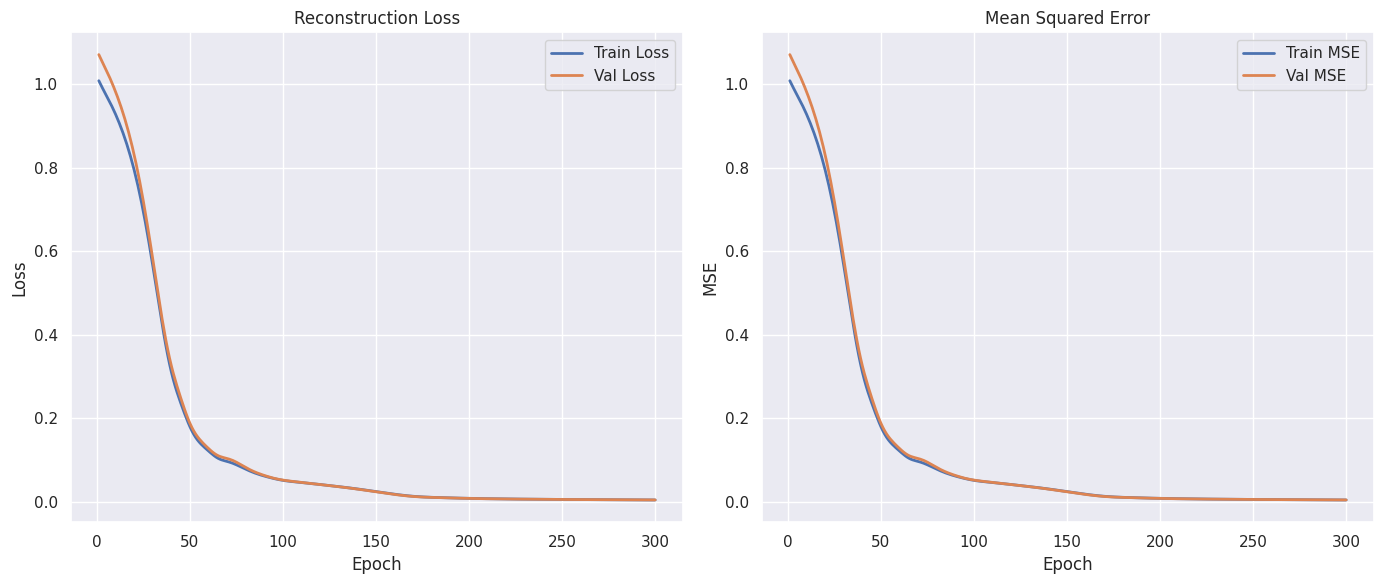

Pretext Task | Epoch 0300/300
train_loss=0.0039 | val_loss=0.0040 | train_mse=0.0039 | val_mse=0.0040


,train_loss,val_loss
295,0.003980,0.004069
296,0.003958,0.004050
297,0.003937,0.004030
298,0.003915,0.004011
299,0.003894,0.003992


In [5]:
reconstruction_history = train_reconstruction_model(
    model=self_supervised_model,
    train_loader=reconstruction_train_loader,
    val_loader=reconstruction_val_loader,
    epochs=PRETEXT_EPOCHS,
)

torch.save(
    {
        "model_state_dict": self_supervised_model.state_dict(),
    },
    SSL_ROOT / "ssl_autoencoder.pt",
)
torch.save(
    {
        "model_state_dict": encoder_model.state_dict(),
    },
    SSL_ROOT / "ssl_encoder.pt",
)

reconstruction_history.tail()


In [6]:
encoded_features_train = encode_features(encoder_model, X_train, BATCH_SIZE)
encoded_features_val = encode_features(encoder_model, X_val, BATCH_SIZE)
encoded_features_test = encode_features(encoder_model, X_test, BATCH_SIZE)
encoded_features_bcu = encode_features(encoder_model, X_bcu, BATCH_SIZE)

np.save(SSL_ROOT / "encoded_features_train.npy", encoded_features_train)
np.save(SSL_ROOT / "encoded_features_val.npy", encoded_features_val)
np.save(SSL_ROOT / "encoded_features_test.npy", encoded_features_test)
np.save(SSL_ROOT / "encoded_features_bcu.npy", encoded_features_bcu)

classifier_train_dataset = TensorDataset(
    torch.tensor(encoded_features_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1),
)
classifier_val_dataset = TensorDataset(
    torch.tensor(encoded_features_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32).unsqueeze(1),
)
classifier_test_dataset = TensorDataset(
    torch.tensor(encoded_features_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1),
)
classifier_bcu_dataset = TensorDataset(
    torch.tensor(encoded_features_bcu, dtype=torch.float32),
)

classifier_train_loader = DataLoader(
    classifier_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
classifier_val_loader = DataLoader(
    classifier_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
classifier_test_loader = DataLoader(
    classifier_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
classifier_bcu_loader = DataLoader(
    classifier_bcu_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("encoded train:", encoded_features_train.shape)
print("encoded val:", encoded_features_val.shape)
print("encoded test:", encoded_features_test.shape)
print("encoded bcu:", encoded_features_bcu.shape)


encoded train: (1604, 32)
encoded val: (200, 32)
encoded test: (201, 32)
encoded bcu: (1115, 32)


In [7]:
classification_model = nn.Sequential(
    nn.Linear(encoded_features_train.shape[1], 1),
    nn.Sigmoid(),
).to(device)

print(classification_model)


Sequential(
  (0): Linear(in_features=32, out_features=1, bias=True)
  (1): Sigmoid()
)


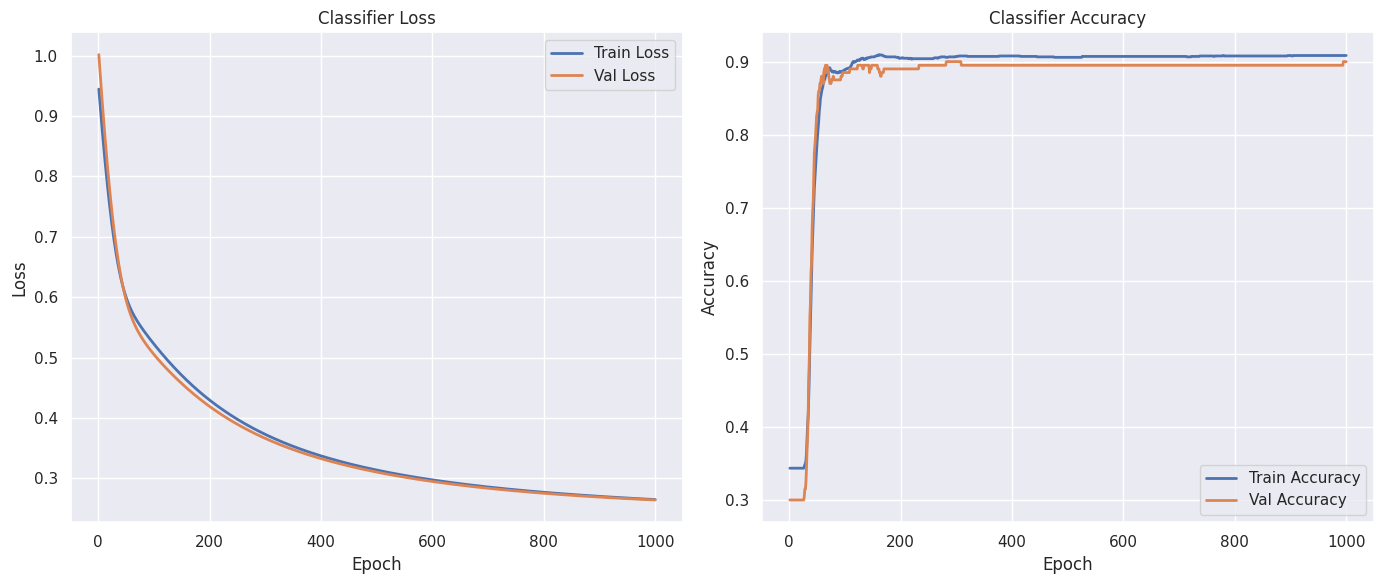

Classifier Head | Epoch 1000/1000
train_loss=0.2648 | val_loss=0.2641 | train_acc=0.9084 | val_acc=0.9000


,train_loss,val_loss,train_accuracy,val_accuracy
995,0.264945,0.264252,0.908354,0.9
996,0.264897,0.264209,0.908354,0.9
997,0.264850,0.264167,0.908354,0.9
998,0.264803,0.264125,0.908354,0.9
999,0.264755,0.264083,0.908354,0.9


In [8]:
classifier_history = train_classifier_head(
    model=classification_model,
    train_loader=classifier_train_loader,
    val_loader=classifier_val_loader,
    epochs=CLASSIFIER_EPOCHS,
    checkpoint_dir=SSL_CKPT_DIR,
)

torch.save(
    {
        "model_state_dict": classification_model.state_dict(),
    },
    SSL_ROOT / "ssl_classifier_head_last.pt",
)

classifier_history.tail()


In [9]:
checkpoint_files = sorted(SSL_CKPT_DIR.glob("weights_epoch_*.pt"))
val_rows = []

for checkpoint_path in checkpoint_files:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    val_model = nn.Sequential(
        nn.Linear(encoded_features_train.shape[1], 1),
        nn.Sigmoid(),
    ).to(device)

    val_model.load_state_dict(checkpoint["model_state_dict"])
    val_model.eval()

    val_probabilities, val_targets = collect_outputs(val_model, classifier_val_loader)
    criterion = nn.BCELoss()
    val_loss_sum = 0.0

    with torch.no_grad():
        for features_batch, targets_batch in classifier_val_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)
            probabilities = val_model(features_batch)
            loss = criterion(probabilities, targets_batch)
            val_loss_sum += loss.item() * targets_batch.size(0)

    metrics = compute_metrics(val_targets, val_probabilities)
    metrics["epoch"] = int(checkpoint["epoch"])
    metrics["checkpoint_path"] = str(checkpoint_path)
    metrics["loss"] = val_loss_sum / len(classifier_val_loader.dataset)
    val_rows.append(metrics)

val_results_df = pd.DataFrame(val_rows).sort_values("epoch").reset_index(drop=True)

metrics_to_track = [
    "loss",
    "accuracy",
    "auc",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "precision_0",
    "precision_1",
    "recall_0",
    "recall_1",
    "f1_0",
    "f1_1",
]

best_rows = []
for metric_name in metrics_to_track:
    if metric_name == "loss":
        best_idx = val_results_df[metric_name].idxmin()
    else:
        best_idx = val_results_df[metric_name].idxmax()

    best_row = val_results_df.loc[best_idx]
    best_rows.append(
        {
            "metric": metric_name,
            "epoch": int(best_row["epoch"]),
            "score": float(best_row[metric_name]),
            "checkpoint_path": best_row["checkpoint_path"],
        }
    )

best_by_metric_df = pd.DataFrame(best_rows).set_index("metric")

print("Best validation epoch for each metric:")
best_by_metric_df


Best validation epoch for each metric:


,epoch,score,checkpoint_path
metric,,,
loss,1000,0.264083,ssl_ptetext_ckpt/weights_epoch_1000.pt
accuracy,282,0.900000,ssl_ptetext_ckpt/weights_epoch_0282.pt
auc,43,0.955238,ssl_ptetext_ckpt/weights_epoch_0043.pt
precision_weighted,282,0.899223,ssl_ptetext_ckpt/weights_epoch_0282.pt
recall_weighted,282,0.900000,ssl_ptetext_ckpt/weights_epoch_0282.pt
f1_weighted,282,0.899507,ssl_ptetext_ckpt/weights_epoch_0282.pt
precision_0,27,1.000000,ssl_ptetext_ckpt/weights_epoch_0027.pt
precision_1,123,0.933333,ssl_ptetext_ckpt/weights_epoch_0123.pt
recall_0,96,0.978571,ssl_ptetext_ckpt/weights_epoch_0096.pt


Testing checkpoint from metric 'loss' at epoch 1000
accuracy              0.880597
auc                   0.951778
precision_weighted    0.887726
recall_weighted       0.880597
f1_weighted           0.882657
dtype: float64

              precision    recall  f1-score   support

         BLL      0.940     0.887     0.913       142
        FSRQ      0.761     0.864     0.810        59

    accuracy                          0.881       201
   macro avg      0.851     0.876     0.861       201
weighted avg      0.888     0.881     0.883       201



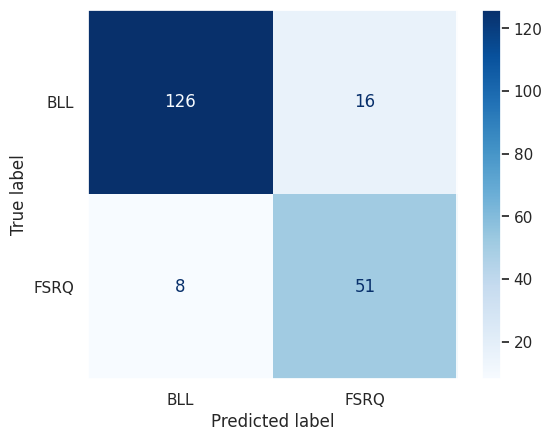

In [10]:
SELECTED_METRIC = "loss"
SELECTED_TEST_EPOCH = int(best_by_metric_df.loc[SELECTED_METRIC, "epoch"])
print(f"Testing checkpoint from metric '{SELECTED_METRIC}' at epoch {SELECTED_TEST_EPOCH}")

selected_checkpoint = SSL_CKPT_DIR / f"weights_epoch_{SELECTED_TEST_EPOCH:04d}.pt"
selected_state = torch.load(selected_checkpoint, map_location=device, weights_only=False)

test_model = nn.Sequential(
    nn.Linear(encoded_features_train.shape[1], 1),
    nn.Sigmoid(),
).to(device)

test_model.load_state_dict(selected_state["model_state_dict"])
test_model.eval()

test_probabilities, test_targets = collect_outputs(test_model, classifier_test_loader)
test_predictions = (test_probabilities >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(test_targets, test_predictions),
    "auc": roc_auc_score(test_targets, test_probabilities),
    "precision_weighted": precision_score(test_targets, test_predictions, average="weighted", zero_division=0),
    "recall_weighted": recall_score(test_targets, test_predictions, average="weighted", zero_division=0),
    "f1_weighted": f1_score(test_targets, test_predictions, average="weighted", zero_division=0),
}

print(pd.Series(test_metrics))
print()
print(classification_report(test_targets, test_predictions, target_names=["BLL", "FSRQ"], digits=3))

sns.set(style="dark")
cm = confusion_matrix(test_targets, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BLL", "FSRQ"])
disp.plot(cmap="Blues")
# plt.title(f"SSL Test Confusion Matrix - Epoch {SELECTED_TEST_EPOCH}")
plt.savefig(SSL_ROOT / "SSL_PTT_Test_CM.png", dpi=300)
plt.show()


In [11]:
true_labels = np.asarray(test_targets).reshape(-1).astype(int)
pred_probs = np.asarray(test_probabilities).reshape(-1)

label_map = {0: "BLL", 1: "FSRQ"}

results_df = pd.DataFrame({
    "true_label": pd.Series(true_labels).map(label_map),
    "BLL": 1 - pred_probs,
    "FSRQ": pred_probs,
})

output_path = SSL_ROOT / "SSL_PTT_Test_Predictions.csv"
results_df.to_csv(output_path, index=False)

print("Saved to:", output_path.resolve())
results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/ssl_pretext_outputs/SSL_PTT_Test_Predictions.csv


,true_label,BLL,FSRQ
0,FSRQ,0.029572,0.970428
1,BLL,0.942061,0.057939
2,BLL,0.441103,0.558897
3,BLL,0.942702,0.057298
4,BLL,0.970199,0.029801


In [12]:
test_model.load_state_dict(selected_state["model_state_dict"])
test_model.eval()

bcus_probabilities = collect_outputs_unlabeled(test_model, classifier_bcu_loader)
bcus_predictions = (test_probabilities >= 0.5).astype(int)


In [13]:
bcus_results_df = pd.DataFrame({
    "BLL": 1 - np.asarray(bcus_probabilities).reshape(-1),
    "FSRQ": np.asarray(bcus_probabilities).reshape(-1),
})

bcus_output_path = SSL_ROOT / "SSL_PTT_BCU_Predictions.csv"
bcus_results_df.to_csv(bcus_output_path, index=False)

print("Saved to:", bcus_output_path.resolve())
bcus_results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/ssl_pretext_outputs/SSL_PTT_BCU_Predictions.csv


,BLL,FSRQ
0,0.630647,0.369353
1,0.943636,0.056364
2,0.947816,0.052184
3,0.972838,0.027162
4,0.970909,0.029091


### Testing

In [14]:
from utils import analyze_prediction_sets, create_and_plot_histograms_test_csv

BLL count : 134
FSRQ count: 67


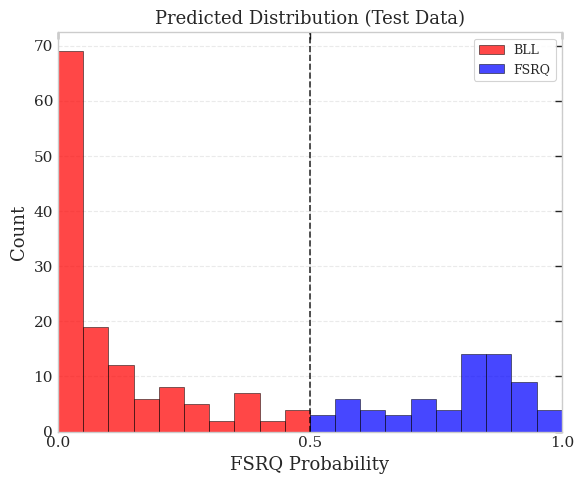

In [15]:
create_and_plot_histograms_test_csv(
    test_csv_path='./ssl_pretext_outputs/SSL_PTT_Test_Predictions.csv',
    title='Predicted Distribution (Test Data)',
    save_path='./ssl_pretext_outputs/SSL_PTT_Test_histogram.png',
)

BLL count : 739
FSRQ count: 376


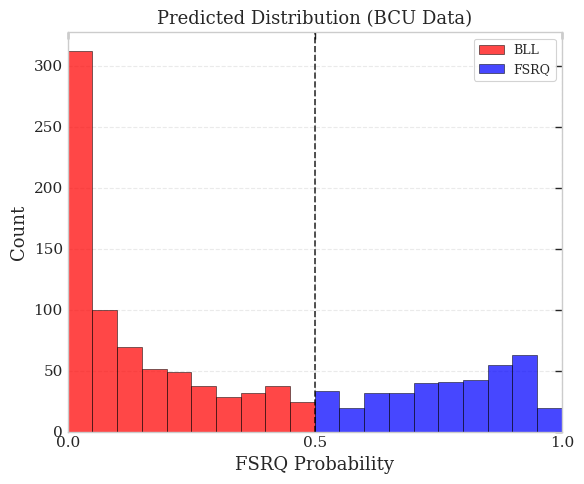

In [16]:
create_and_plot_histograms_test_csv(
    test_csv_path='./ssl_pretext_outputs/SSL_PTT_BCU_Predictions.csv',
    title='Predicted Distribution (BCU Data)',
    save_path='./ssl_pretext_outputs/SSL_PTT_BCU_histogram.png',
)

Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.4389761686325073
qhat_FSRQ       : 0.5794210731983184

Prediction-set counts at fixed alpha
BLL only : 129
FSRQ only: 71
Both set : 1
Empty set: 0
Total    : 201


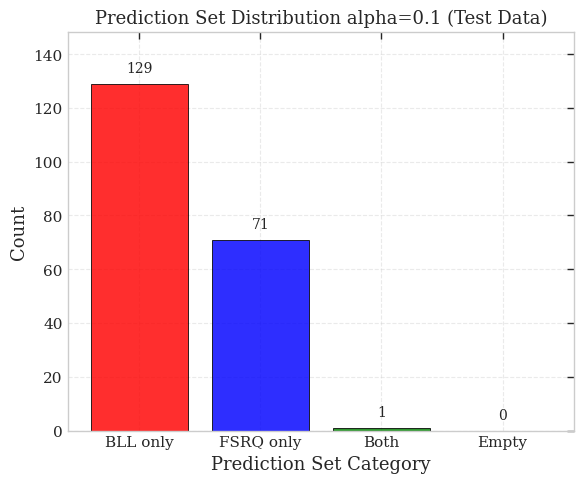

In [17]:
results = analyze_prediction_sets(
    qhat_csv='./ssl_pretext_outputs/ssl_pretext_qhat_mccp.csv',
    test_csv='./ssl_pretext_outputs/SSL_PTT_Test_Predictions.csv',
    alpha_target=0.1,
    save_path='./ssl_pretext_outputs/SSL_PTT_Test_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (Test Data)",
)


Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.4389761686325073
qhat_FSRQ       : 0.5794210731983184

Prediction-set counts at fixed alpha
BLL only : 693
FSRQ only: 412
Both set : 10
Empty set: 0
Total    : 1115


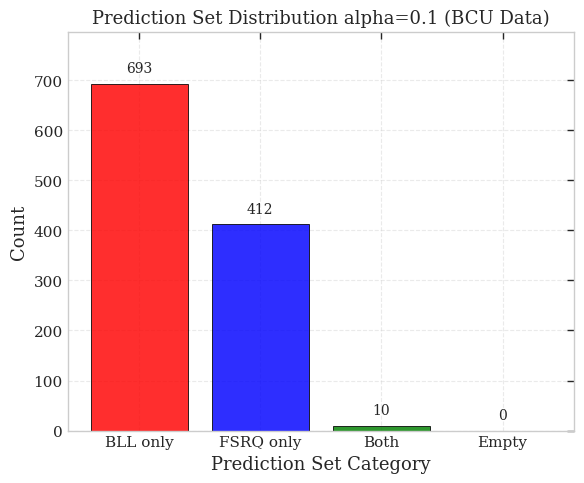

In [18]:
results_bcu = analyze_prediction_sets(
    qhat_csv='./ssl_pretext_outputs/ssl_pretext_qhat_mccp.csv',
    test_csv='./ssl_pretext_outputs/SSL_PTT_BCU_Predictions.csv',
    alpha_target=0.1,
    save_path='./ssl_pretext_outputs/SSL_PTT_BCU_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (BCU Data)",
)


In [19]:
prefix = "SSL_PTT"
alpha = 0.1
random_state = 0

def save_plot_bundle(mcp, output_dir, prefix=prefix, include_fig2_scatter=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mcp.plot_all(
        output_dir=str(output_dir),
        prefix=prefix,
        show=False,
        include_fig2_scatter=include_fig2_scatter,
    )

    png_plotters = [
        ("coverage", mcp.plot_coverage),
        ("setsize", mcp.plot_set_size),
        ("roc", mcp.plot_roc),
        ("alpha_metrics", mcp.plot_alpha_metrics),
    ]
    if include_fig2_scatter:
        png_plotters.append(("scatter", mcp.plot_prediction_set_scatter))

    for name, plotter in png_plotters:
        plotter(save_path=output_dir / f"{prefix}_{name}.png", show=False)
        

['FSRQ' 'BLL']
['true_label', 'BLL', 'FSRQ']
Qhat rows   : 52 alpha values
Test        : 201 samples
Classes     : ['BLL', 'FSRQ']

Running unified alpha sweep …
Computing macro ROC …

Macro AUC = 0.9518 | MCP AUC ≈ 0.9437

-----------------------------------------------
  MCP Metrics Summary   alpha = 0.1000
-----------------------------------------------
  Calibration samples : 1604
  Test samples        : 201
  Classes             : 2
-----------------------------------------------
  Coverage            : 0.8607   (target >= 0.9000)
  Macro F1-score      : 0.8378
  Average set size    : 1.0050
  Singleton rate      : 0.8557
  True positive rate  : 0.8607
  False positive rate : 0.1443
-----------------------------------------------
  Per-class F1:
    BLL                          0.8971
    FSRQ                         0.7786
-----------------------------------------------
  Saved: ssl_pretext_outputs/SSL_PTT_coverage.pdf
  Saved: ssl_pretext_outputs/SSL_PTT_setsize.pdf
  Saved: ssl

alpha                0.100000
n_cal             1604.000000
n_test             201.000000
n_classes            2.000000
coverage             0.860697
macro_f1             0.837842
avg_set_size         1.004975
singleton_rate       0.855721
fpr                  0.144279
tpr                  0.860697
dtype: float64

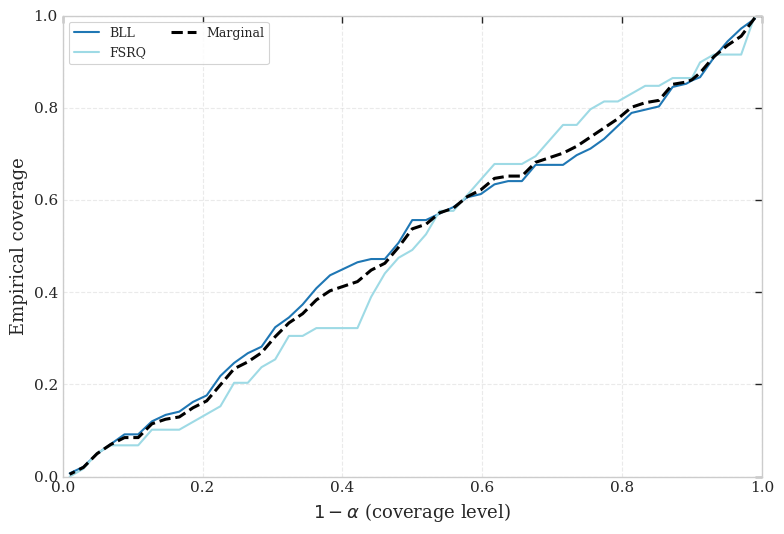

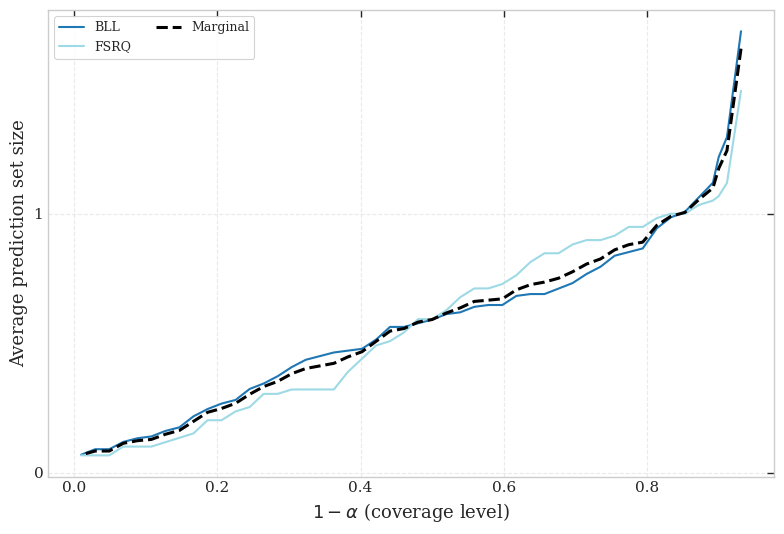

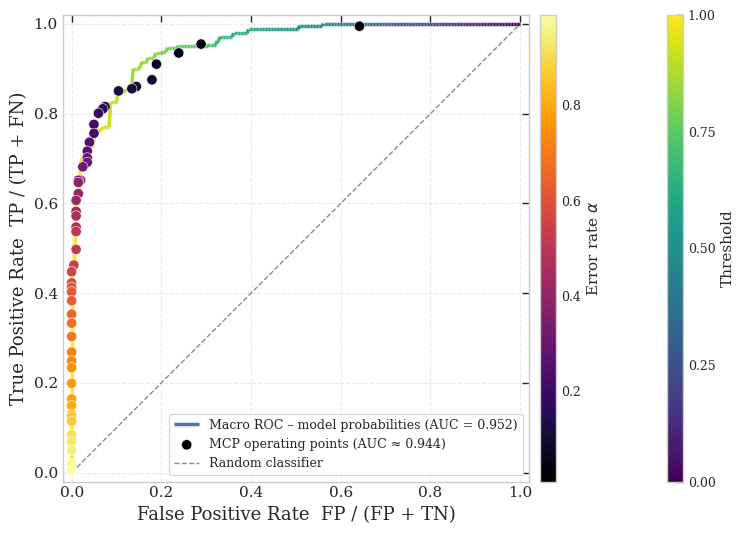

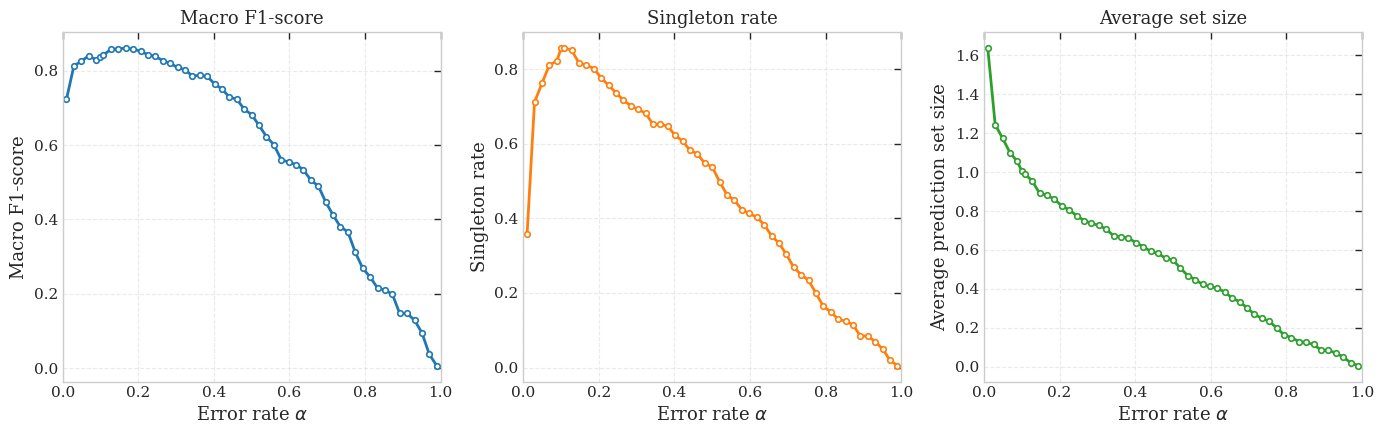

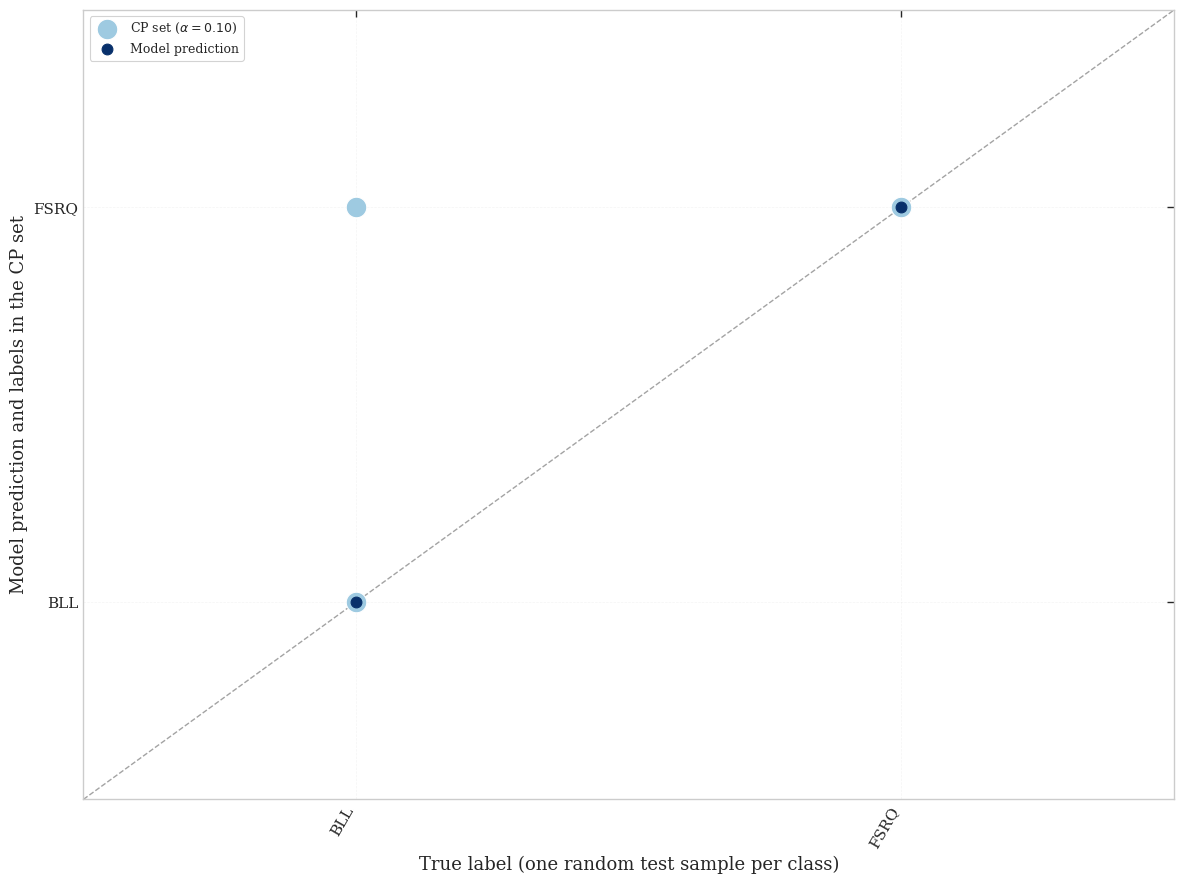

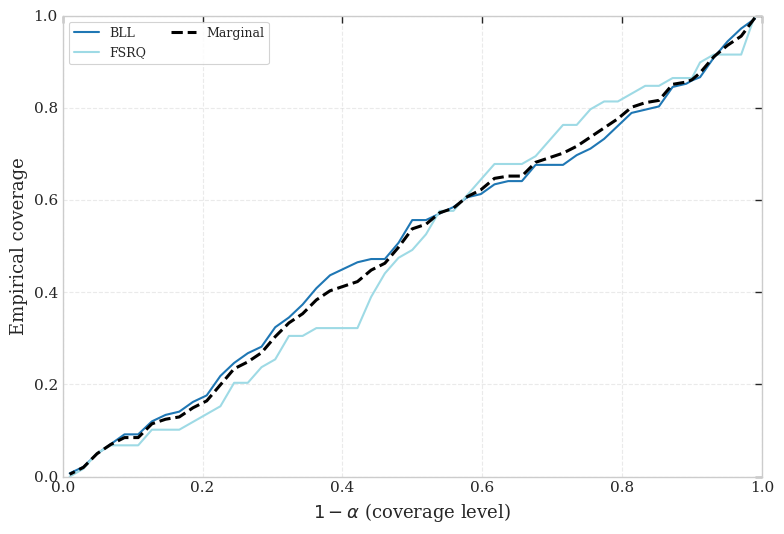

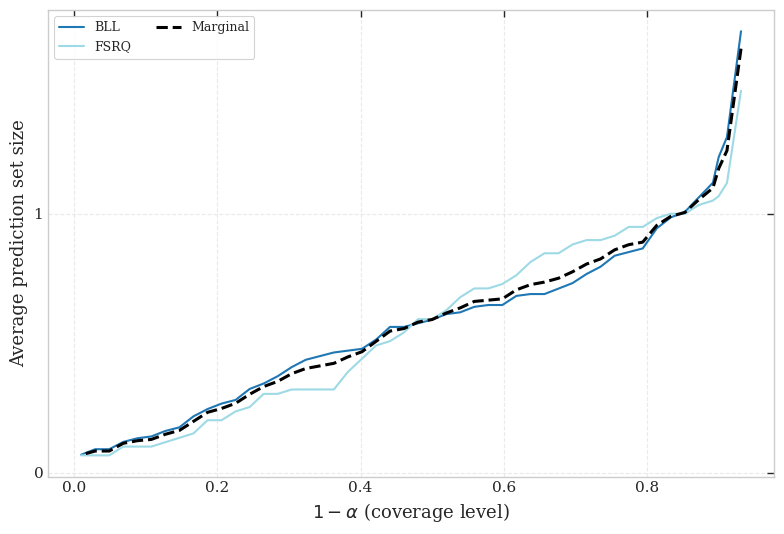

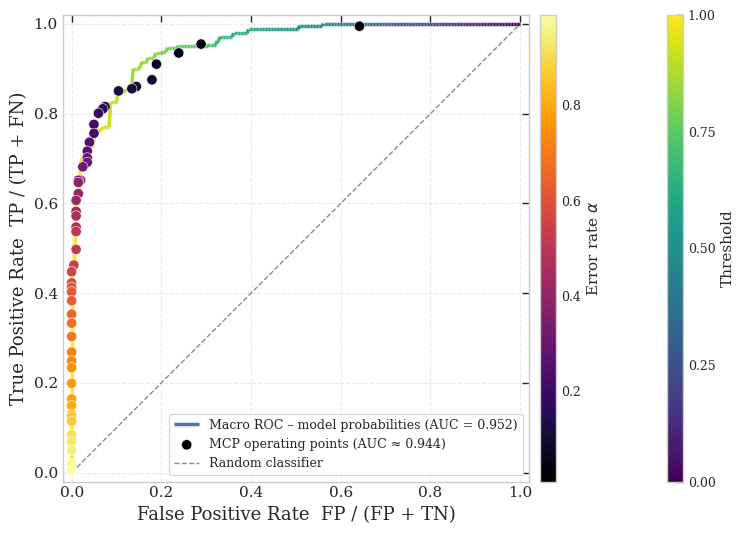

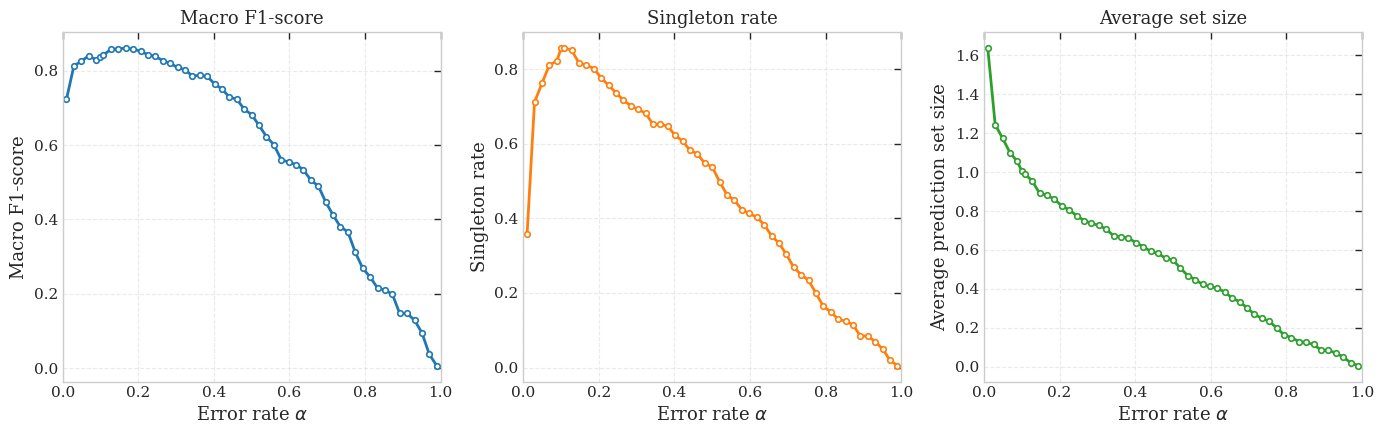

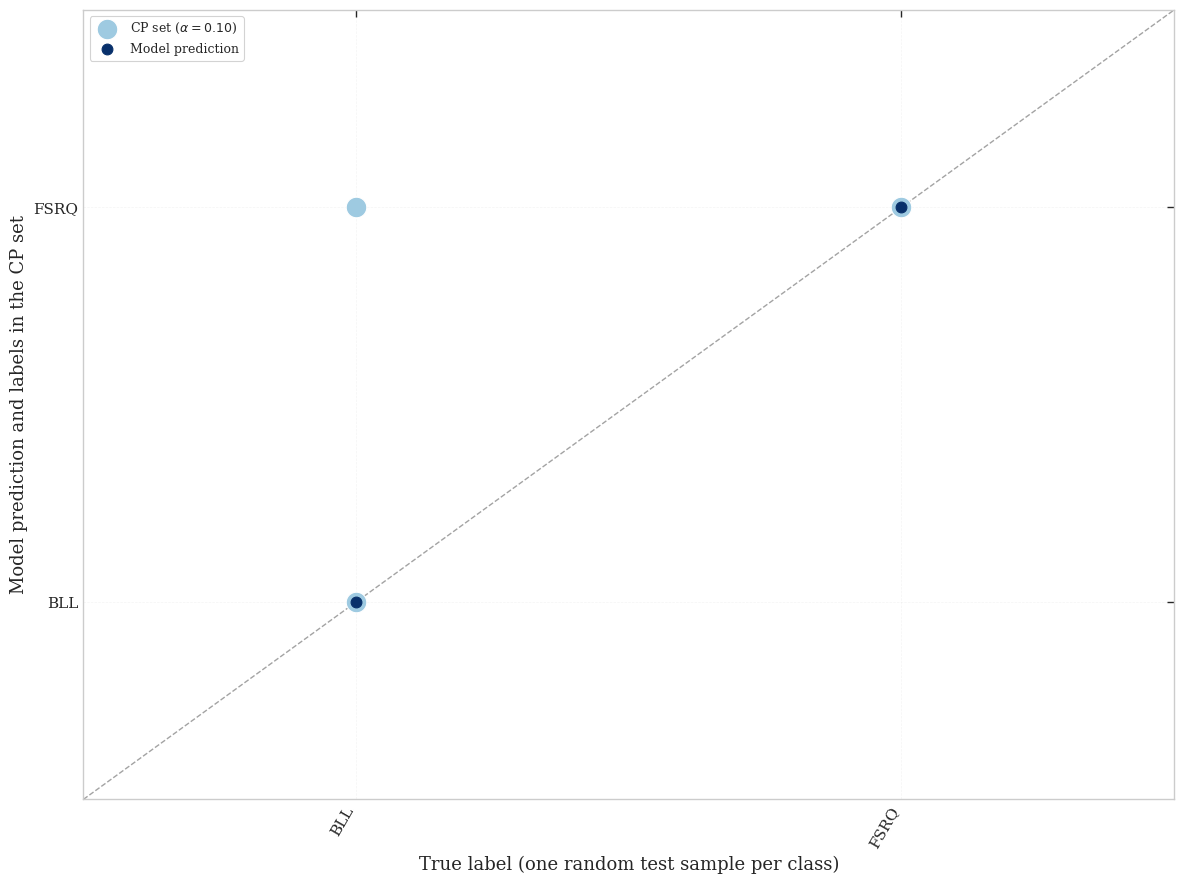

In [20]:
qhat_csv = './ssl_pretext_outputs/ssl_pretext_qhat_mccp.csv'
test_csv = './ssl_pretext_outputs/SSL_PTT_Test_Predictions.csv'

test_df = pd.read_csv(test_csv)

print(test_df["true_label"].unique())   # should already show ['BLL', 'FSRQ'] or ['FSRQ', 'BLL']
print(test_df.columns.tolist())         # should show ['true_label', 'BLL', 'FSRQ']

mcp_qhat = MCPTool.from_qhat_csv(
    qhat_csv,
    test_csv,
    alpha=alpha,
    random_state=random_state,
).run()

save_plot_bundle(mcp_qhat, SSL_ROOT)

summary = mcp_qhat.print_metrics()
pd.Series({k: v for k, v in summary.items() if k != "per_label_f1"})